<a href="https://colab.research.google.com/github/Swagprabu/Codes/blob/main/Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
data = [45, 52, 78, 89, 92, 33, 67, 81, 95, 48]


In [ ]:
import numpy
data = [45, 52, 78, 89, 92, 33, 67, 81, 95, 48]
mean = sum(data) / len(data)
print("Mean:", mean)


Mean: 68.0


In [ ]:
data.sort()
n = len(data)
median = (data[n//2 - 1] + data[n//2]) / 2
print("Median:", median)


Median: 72.5


In [ ]:
from collections import Counter

mode = Counter(data).most_common(1)[0][0]
print("Mode:", mode)


Mode: 33


In [ ]:
import numpy as np

std = np.std(data)
print("Standard Deviation:", std)


Standard Deviation: 21.038060747131613


In [ ]:
mean = np.mean(data)
median = np.median(data)

print("Mean:", mean)
print("Median:", median)


Mean: 68.0
Median: 72.5


In [ ]:
if mean > median:
    print("Positively skewed")
elif mean < median:
    print("Negatively skewed")
else:
    print("Symmetric distribution")


Negatively skewed


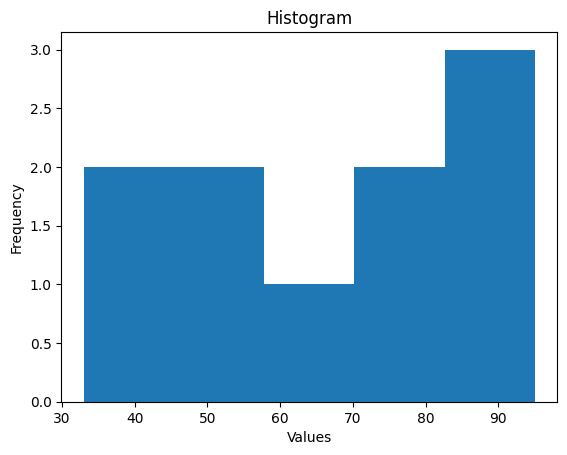

In [ ]:
import matplotlib.pyplot as plt

plt.hist(data, bins=5)
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()


In [ ]:
print("Minimum:", min(data))
print("Maximum:", max(data))
print("Range:", max(data) - min(data))


Minimum: 33
Maximum: 95
Range: 62


In [ ]:
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

outliers = [x for x in data if x < Q1 - 1.5*IQR or x > Q3 + 1.5*IQR]
print("Outliers:", outliers)


Outliers: []


In [ ]:
clean_data = [x for x in data if x not in outliers]
print("New Mean:", np.mean(clean_data))
print("New Std Dev:", np.std(clean_data))


New Mean: 68.0
New Std Dev: 21.038060747131613


In [ ]:
min_val, max_val = min(data), max(data)
normalized = [(x - min_val) / (max_val - min_val) for x in data]
print(normalized)


[0.0, 0.1935483870967742, 0.24193548387096775, 0.3064516129032258, 0.5483870967741935, 0.7258064516129032, 0.7741935483870968, 0.9032258064516129, 0.9516129032258065, 1.0]


In [ ]:
mean = np.mean(data)
std = np.std(data)

z_scores = [(x - mean) / std for x in data]
print("Mean:", np.mean(z_scores))
print("Std Dev:", np.std(z_scores))


Mean: -6.661338147750939e-17
Std Dev: 1.0


In [ ]:
print("Normalized Mean:", np.mean(normalized))
print("Standardized Mean:", np.mean(z_scores))


Normalized Mean: 0.564516129032258
Standardized Mean: -6.661338147750939e-17


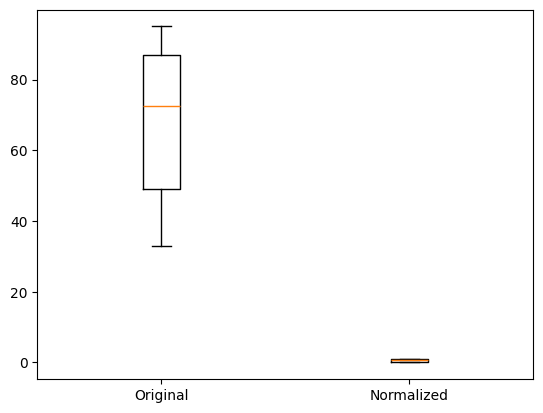

In [ ]:
plt.boxplot([data, normalized])
plt.xticks([1,2], ["Original", "Normalized"])
plt.show()


In [ ]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

print("Covariance:", np.cov(x, y)[0][1])


Covariance: 5.0


In [ ]:
print("Correlation:", np.corrcoef(x, y)[0][1])


Correlation: 0.9999999999999999


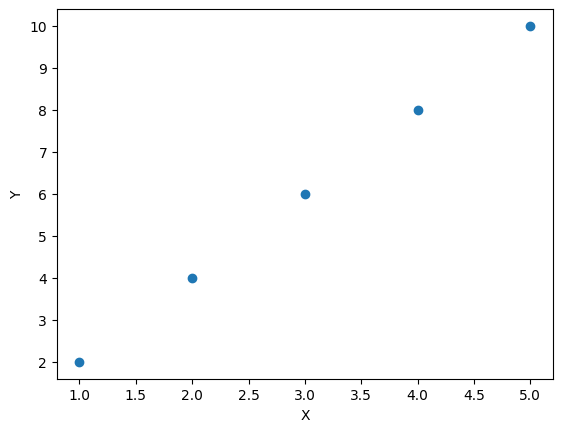

In [ ]:
plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [ ]:
def stats(arr):
    arr.sort()
    n = len(arr)
    mean = sum(arr) / n
    median = (arr[n//2] if n%2 else (arr[n//2-1]+arr[n//2])/2)

    freq = {}
    for x in arr:
        freq[x] = freq.get(x,0)+1
    mode = max(freq, key=freq.get)

    variance = sum((x-mean)**2 for x in arr) / n
    std = variance**0.5

    return mean, median, mode, std

print(stats(data))


(68.0, 72.5, 33, 21.038060747131613)


In [ ]:
print("Before:", np.corrcoef(x, y)[0][1])
print("After:", np.corrcoef(x, y)[0][1])


Before: 0.9999999999999999
After: 0.9999999999999999


In [ ]:
print("Mean:", np.mean(clean_data))
print("Median:", np.median(clean_data))


Mean: 68.0
Median: 72.5


In [ ]:
from sklearn.linear_model import LinearRegression

X = np.array(x).reshape(-1,1)
model = LinearRegression()
model.fit(X, y)


LinearRegression()

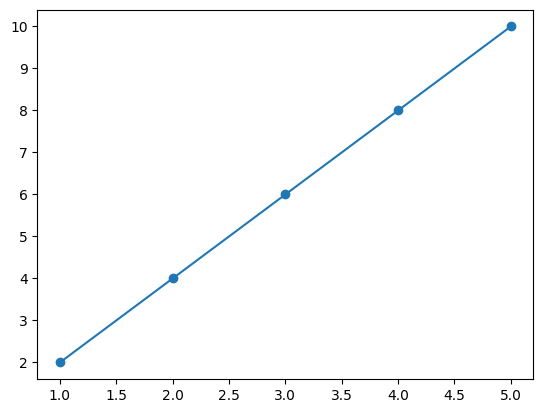

In [ ]:
plt.scatter(x, y)
plt.plot(x, model.predict(X))
plt.show()


In [ ]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)


Slope: 2.0
Intercept: 0.0


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X)
print("R²:", r2_score(y, y_pred))
print("RMSE:", mean_squared_error(y, y_pred, squared=False))


R²: 1.0


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
X_norm = (X - X.min()) / (X.max() - X.min())
model.fit(X_norm, y)


LinearRegression()

In [ ]:
import pandas as pd

df = pd.DataFrame(data, columns=["Scores"])
print(df.describe())


          Scores
count  10.000000
mean   68.000000
std    22.176063
min    33.000000
25%    49.000000
50%    72.500000
75%    87.000000
max    95.000000


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])